In [1]:
import os
# Disable tokenizers parallelism
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
# os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [2]:
!pip install datasets evaluate transformers[sentencepiece]
!pip install git+https://github.com/csebuetnlp/normalizer
!pip install accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.0 MB/s eta 0:00:00
  Cloning https://github.com/csebuetnlp/normalizer to /tmp/pip-req-build-pgqh992j
  Running command git clone --filter=blob:none --quiet https://github.com/csebuetnlp/normalizer /tmp/pip-req-build-pgqh992j
  Resolved https://github.com/csebuetnlp/normalizer to commit d405944dde5ceeacb7c2fd3245ae2a9dea5f35c9
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for normalizer: filename=normalizer-0.0.1-py3-none-any.whl size=6859 sha256=e26cad2739714e2a5cc95d597f750b2a3b4cc7212152d47fbdabba13096425a8
  Stored in directory: /tmp/pip-ephem-wheel-cache-vqze17a8/wheels/2e/79/9c/cd96d490298305d51d2da11484bb2c25fd1f759a6906708282
  Created wheel for emoji: filename=emoji-1.4.

In [3]:
#!pip uninstall tensorflow transformers datasets evaluate
!pip install tensorflow transformers datasets evaluate imblearn

In [4]:
import pandas as pd
from collections import Counter
import re
#from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding
import evaluate
#from datasets import load_metric
#import datasets
#pd.set_option('display.max_rows', 500)
#pd.set_option('display.max_columns', 500)
#pd.set_option('display.width', 1000)
#from datasets import Dataset, DatasetDict
from transformers import BertModel, BertTokenizer, AdamW, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import random
np.object = object
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from transformers import AutoTokenizer, DataCollatorWithPadding,BertModel,AutoTokenizer,AutoConfig,RobertaModel
from transformers import RobertaTokenizer, RobertaModel
from collections import defaultdict
import torch
import warnings
warnings.filterwarnings('ignore')
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from transformers import AdamW
from sklearn.model_selection import KFold
from torch.cuda import amp

import gc
gc.enable()

In [5]:
def set_random_seed(random_seed):
    random.seed(random_seed)
    np.random.seed(random_seed)
    os.environ["PYTHONHASHSEED"] = str(random_seed)

    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)

    torch.backends.cudnn.deterministic = True

In [1]:
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
model_name = "XLM-RoBERTa-base"
title = "for Token Classification Using " + model_name
title_figure = "/kaggle/working/ITN_" + model_name
model_path = "/kaggle/working/"+ model_name
# Load data from CSV
df_input = pd.read_csv('/kaggle/input/ec-and-tn-datasets/_115000_TN_Oversampled_Final_Data.csv', encoding='utf-16')
df_input['CLASS'].value_counts()

CLASS
BNG_TEXT         115000
ENG_TEXT         115000
ORDINAL          115000
FLOAT            115000
FRACTIONAL       115000
DATE             115000
TELEPHONE        115000
GAME             115000
PERCENTAGE       115000
EQUATION         115000
HOMO_TEXT        115000
RANGE            115000
NON_HOMO_TEXT    115000
CARDINAL         115000
ROMAN_NUM        115000
MONEY            115000
ENG_NUM          115000
YEAR             115000
TIME             115000
ARABIC_TEXT      115000
OTHERS_TEXT      115000
PUNCTUATION      115000
UNKNOWN_TEXT     115000
SPECIAL SIGN     115000
ABBREVIATION     115000
EMOZI            115000
Name: count, dtype: int64

In [7]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# Reshape the 'BEFORE SENTENCE' column into a 2D array
X = df_input["AFTER"].values.reshape(-1, 1)  # Reshape to a 2D array
y = df_input["LABEL"]

# Define the desired sampling strategy
undersampling_strategy = {i: 10000 for i in range(26)}

# Create an instance of RandomUnderSampler with the specified sampling strategy
under_sampler = RandomUnderSampler(random_state=2017, sampling_strategy=undersampling_strategy)

# Resample the dataset
X_resampled, y_resampled = under_sampler.fit_resample(X, y )

# Convert X_resampled back to a 1D array if necessary
X_resampled = X_resampled.flatten()

# Create a DataFrame using the resampled data
df = pd.DataFrame({
    'AFTER': X_resampled,  # Feature column
    'LABEL': y_resampled    # Target column
})

# Check the first few rows of the new DataFrame and value counts of labels
df["LABEL"].value_counts()


LABEL
0     100
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
22    100
23    100
24    100
25    100
Name: count, dtype: int64

In [8]:
with pd.option_context('display.max_colwidth',0):
    display(df.sample(n=10))

,AFTER,LABEL
2154,')।,21
220,এক লক্ষ একত্রিশ হাজার অষ্টাবিংশ,2
2036,Υδραυλική,20
2279,Č,22
329,নয় লক্ষ নব্বই হাজার আট শত তিন দশমিক তিন নয় নয় নয় দুই নয় শুণ্য,3
2500,:-(,25
2501,;-),25
2156,.',21
2418,ইংরেজি,24
2351,সমান,23


In [9]:
df.shape

(2600, 2)

In [10]:
df.shape[0]*0.7

1819.9999999999998

In [11]:
df["LABEL"].value_counts()

LABEL
0     100
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
22    100
23    100
24    100
25    100
Name: count, dtype: int64

# Data Visualization 

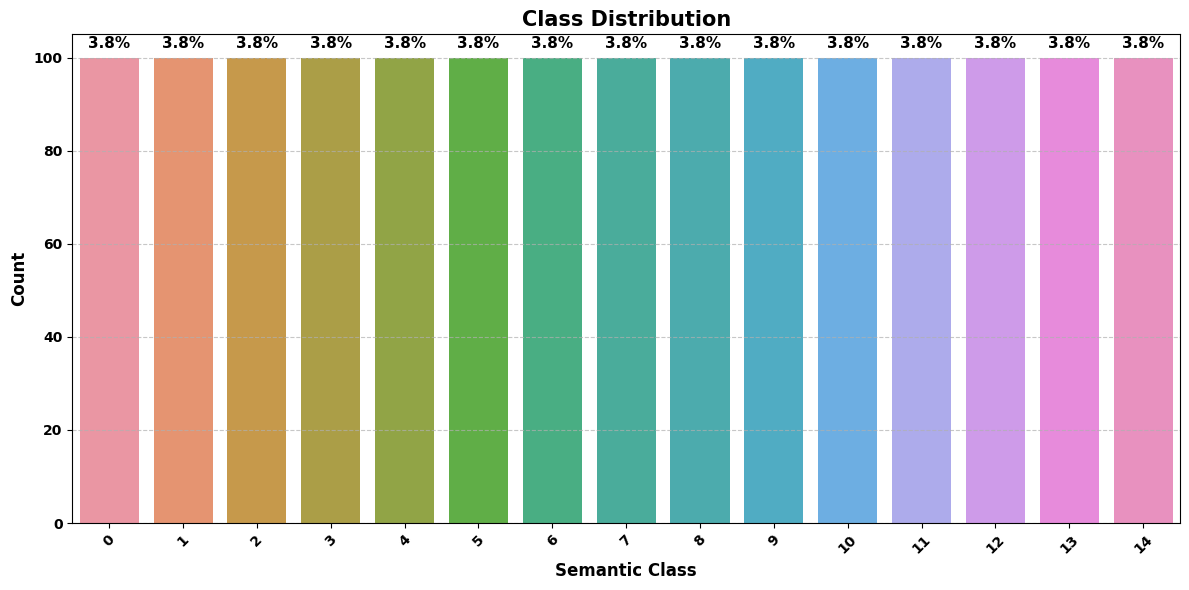

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

def countplot(fig_x, fig_y, col, top_x, rotation, xlabel, title, df):
    """
    Create a count plot with percentage annotations.

    Parameters:
    - fig_x (int): Width of the figure.
    - fig_y (int): Height of the figure.
    - col (str): Column name for counting.
    - top_x (int): Number of top categories to display.
    - rotation (int): Rotation angle for x-axis labels.
    - xlabel (str): Label for the x-axis.
    - title (str): Title of the plot.
    - df (DataFrame): DataFrame containing the data.
    """
    plt.figure(figsize=(fig_x, fig_y))

    # Set the color palette for the plot
    sns.set_palette("viridis")

    # Calculate total count for percentage calculation
    total = float(len(df))

    # Create count plot with a color palette
    ax = sns.countplot(x=col, data=df, order=df[col].value_counts().iloc[:top_x].index)

    # Annotate each bar with the percentage
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + p.get_height()
        ax.annotate(percentage, (x, y), xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', weight='bold', size=11, color='black')

    # Customize plot appearance
    plt.xticks(rotation=rotation, weight='bold', size=10)
    plt.yticks(weight='bold', size=10)
    plt.xlabel(xlabel, weight='bold', size=12)
    plt.ylabel('Count', weight='bold', size=12)
    plt.title(title, weight='bold', size=15)

    # Add grid lines for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Display the plot
    plt.tight_layout()
    plt.show()

# Example usage
countplot(12, 6, 'LABEL', 15, 45, 'Semantic Class', 'Class Distribution', df)


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['AFTER'], df['LABEL'], test_size=0.3, random_state=42, stratify=df['LABEL'])
#X_val, X_test, y_val, y_test = train_test_split(X_test1,y_test1, test_size=0.5, random_state=42, stratify=y_test1)

In [14]:
X_train.shape

(1820,)

In [15]:
train_df = pd.DataFrame()
train_df['AFTER'] = X_train.values
train_df['LABEL'] = y_train.values

In [16]:
train_df.shape

(1820, 2)

In [17]:
train_df.head()

,AFTER,LABEL
0,লেফটেন্যান্ট,24
1,দুই লক্ষ বিশ হাজার ষোল ফ্রাঙ্ক,15
2,205.102E-8,16
3,নয় লক্ষ নব্বই হাজার ছয় শত পাঁচ দশমিক তিন নয় নয়...,3
4,ইউরো,23


In [18]:
test_df = pd.DataFrame()
test_df['AFTER'] = X_test.values
test_df['LABEL'] = y_test.values

In [19]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   AFTER   780 non-null    object
 1   LABEL   780 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 12.3+ KB


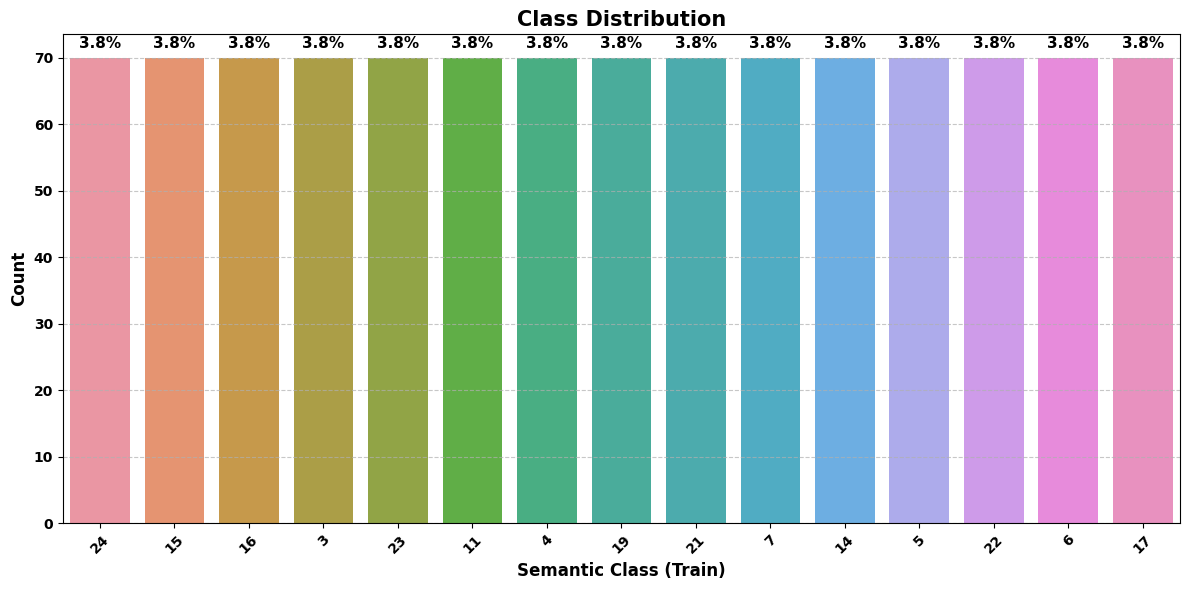

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

def countplot(fig_x, fig_y, col, top_x, rotation, xlabel, title, df):
    """
    Create a count plot with percentage annotations.

    Parameters:
    - fig_x (int): Width of the figure.
    - fig_y (int): Height of the figure.
    - col (str): Column name for counting.
    - top_x (int): Number of top categories to display.
    - rotation (int): Rotation angle for x-axis labels.
    - xlabel (str): Label for the x-axis.
    - title (str): Title of the plot.
    - df (DataFrame): DataFrame containing the data.
    """
    plt.figure(figsize=(fig_x, fig_y))

    # Set the color palette for the plot
    sns.set_palette("viridis")

    # Calculate total count for percentage calculation
    total = float(len(train_df))

    # Create count plot with a color palette
    ax = sns.countplot(x=col, data=train_df, order=train_df[col].value_counts().iloc[:top_x].index)

    # Annotate each bar with the percentage
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + p.get_height()
        ax.annotate(percentage, (x, y), xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', weight='bold', size=11, color='black')

    # Customize plot appearance
    plt.xticks(rotation=rotation, weight='bold', size=10)
    plt.yticks(weight='bold', size=10)
    plt.xlabel(xlabel, weight='bold', size=12)
    plt.ylabel('Count', weight='bold', size=12)
    plt.title(title, weight='bold', size=15)

    # Add grid lines for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Display the plot
    plt.tight_layout()
    plt.show()

# Example usage
countplot(12, 6, 'LABEL', 15, 45, 'Semantic Class (Train)', 'Class Distribution', df)


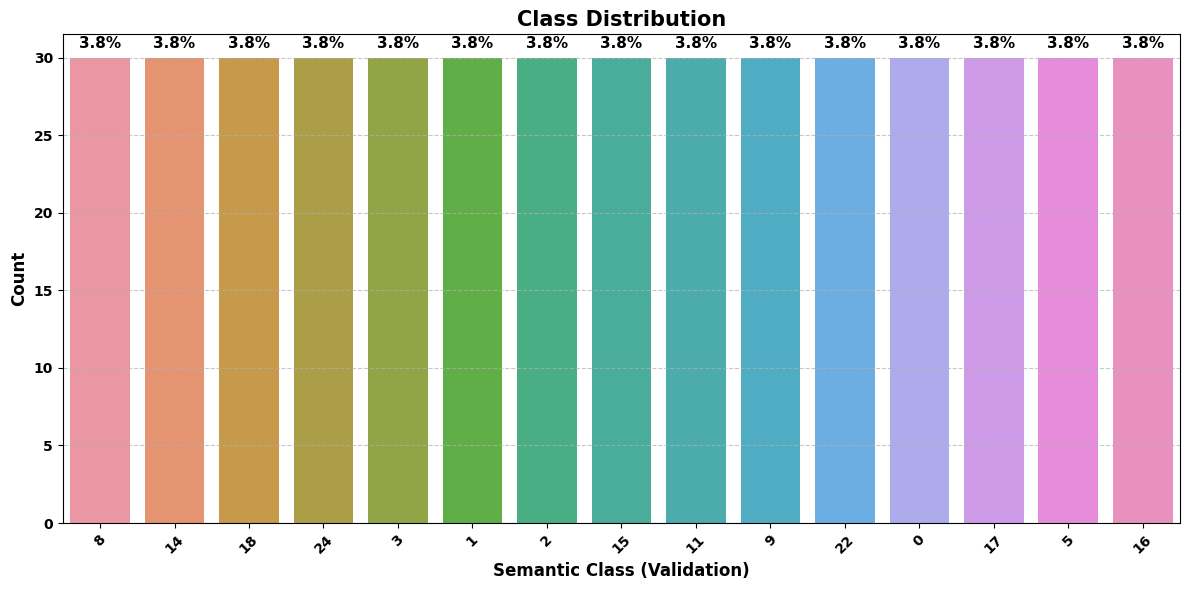

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

def countplot(fig_x, fig_y, col, top_x, rotation, xlabel, title, df):
    """
    Create a count plot with percentage annotations.

    Parameters:
    - fig_x (int): Width of the figure.
    - fig_y (int): Height of the figure.
    - col (str): Column name for counting.
    - top_x (int): Number of top categories to display.
    - rotation (int): Rotation angle for x-axis labels.
    - xlabel (str): Label for the x-axis.
    - title (str): Title of the plot.
    - df (DataFrame): DataFrame containing the data.
    """
    plt.figure(figsize=(fig_x, fig_y))

    # Set the color palette for the plot
    sns.set_palette("viridis")

    # Calculate total count for percentage calculation
    total = float(len(test_df))

    # Create count plot with a color palette
    ax = sns.countplot(x=col, data=test_df, order=test_df[col].value_counts().iloc[:top_x].index)

    # Annotate each bar with the percentage
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + p.get_height()
        ax.annotate(percentage, (x, y), xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', weight='bold', size=11, color='black')

    # Customize plot appearance
    plt.xticks(rotation=rotation, weight='bold', size=10)
    plt.yticks(weight='bold', size=10)
    plt.xlabel(xlabel, weight='bold', size=12)
    plt.ylabel('Count', weight='bold', size=12)
    plt.title(title, weight='bold', size=15)

    # Add grid lines for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Display the plot
    plt.tight_layout()
    plt.show()

# Example usage
countplot(12, 6, 'LABEL', 15, 45, 'Semantic Class (Validation)', 'Class Distribution', df)


In [22]:
class Config:
    num_classes = 26
    path =  "FacebookAI/xlm-roberta-base"
    num_epochs = 10
    batch_size = 32
    SEED = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

config = Config()

In [23]:
# Step 1: Load the XLM-RoBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained(config.path)

# Step 2: Extract vocabulary tokens (assuming you want to use a custom list)
# Here, you'll need to preprocess `df_input["AFTER"]` to extract any unique words you want to add

# Create a list of new tokens (for example, you could tokenize the text and gather new tokens)
new_tokens = set()
for text in df_input["BEFORE"]:
    tokens = tokenizer.tokenize(text)  # Tokenize the text
    new_tokens.update(tokens)  # Add unique tokens
    
for text in df_input["AFTER"]:
    tokens = tokenizer.tokenize(text)  # Tokenize the text
    new_tokens.update(tokens)  # Add unique tokens

# Step 3: Add new tokens to the tokenizer
# Add the tokens to the tokenizer (but ensure they are not already in the tokenizer's vocabulary)
tokenizer.add_tokens(list(new_tokens))

# Continue with the tokenization and training process as before

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

KeyboardInterrupt: 

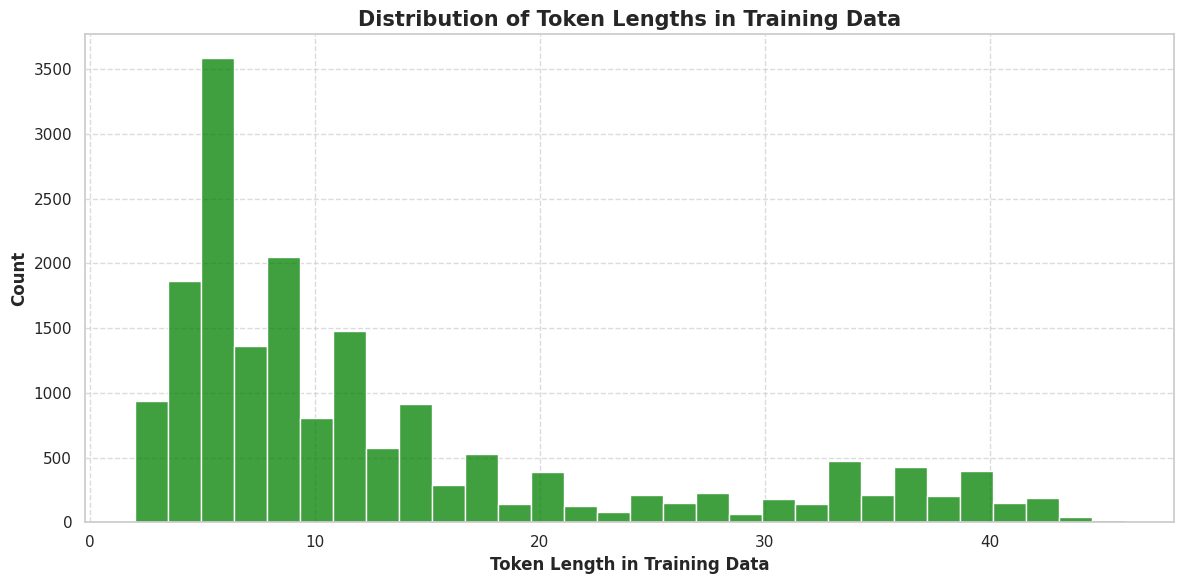

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate token counts
token_counts = []
for _, row in train_df.iterrows():
    token_count = len(tokenizer.encode(
        row["AFTER"],
        max_length=512,
        truncation=True
    ))
    token_counts.append(token_count)

# Set up the figure size and style
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")  # Improve background style for readability

# Plot histogram
sns.histplot(token_counts, bins=30, kde=False, color='green')

# Customize plot appearance
plt.xlabel("Token Length in Training Data", weight='bold', size=12)
plt.ylabel('Count', weight='bold', size=12)
plt.title("Distribution of Token Lengths in Training Data", weight='bold', size=15)
plt.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

# Display the plot
plt.tight_layout()
plt.show()

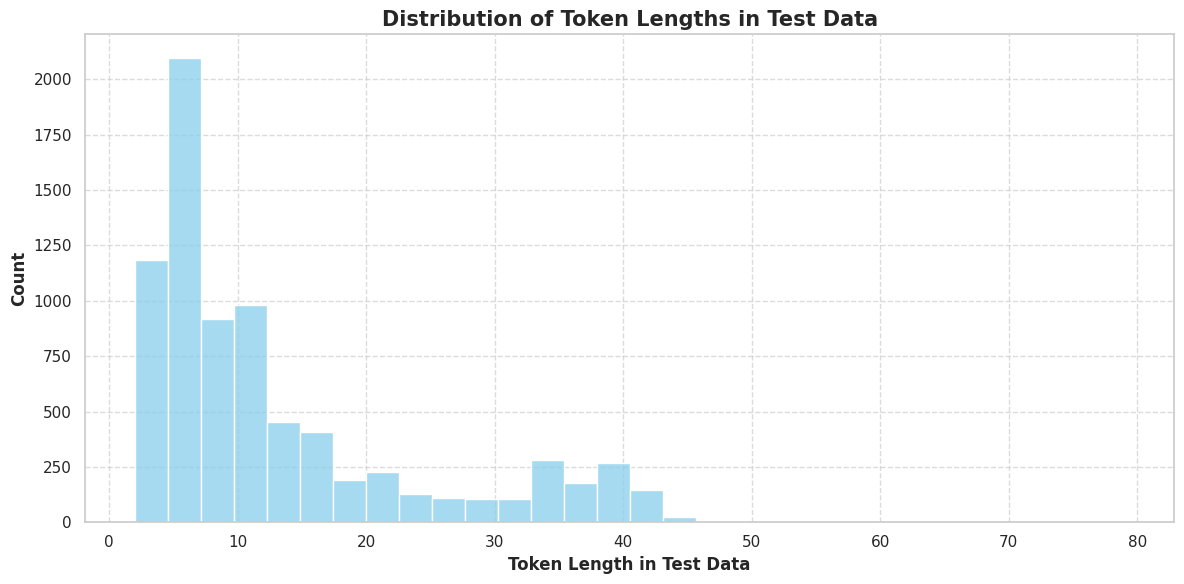

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate token counts for test data
token_counts = []
for _, row in test_df.iterrows():
    token_count = len(tokenizer.encode(
        row["AFTER"],
        max_length=512,
        truncation=True
    ))
    token_counts.append(token_count)

# Set up the figure size and style
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")  # Improve background style for readability

# Plot histogram
sns.histplot(token_counts, bins=30, kde=False, color='skyblue')

# Customize plot appearance
plt.xlabel("Token Length in Test Data", weight='bold', size=12)
plt.ylabel('Count', weight='bold', size=12)
plt.title("Distribution of Token Lengths in Test Data", weight='bold', size=15)
plt.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

# Display the plot
plt.tight_layout()
plt.show()


In [24]:
from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [25]:
max_token_length = 70
def tokenize_function(example):
    return tokenizer(example["AFTER"], padding = True, truncation=True, max_length=max_token_length)

# mapping dataset (actually texts) into tokenized values of pretrained model (provided in path)
tokenized_train_datasets = train_dataset.map(tokenize_function, batched=True)
tokenized_test_datasets = test_dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/1820 [00:00<?, ? examples/s]

Map:   0%|          | 0/780 [00:00<?, ? examples/s]

In [26]:
tokenized_train_datasets

Dataset({
    features: ['AFTER', 'LABEL', 'input_ids', 'attention_mask'],
    num_rows: 1820
})

In [27]:
tokenized_test_datasets

Dataset({
    features: ['AFTER', 'LABEL', 'input_ids', 'attention_mask'],
    num_rows: 780
})

In [28]:
remove_columns = ['AFTER']
tokenized_train_datasets = tokenized_train_datasets.remove_columns(remove_columns)
tokenized_test_datasets = tokenized_test_datasets.remove_columns(remove_columns)
tokenized_train_datasets.set_format("torch")
tokenized_test_datasets.set_format("torch")

In [29]:
tokenized_test_datasets.column_names

['LABEL', 'input_ids', 'attention_mask']

In [30]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModel
class ClassifierModel(nn.Module):

    def __init__(self):
        super(ClassifierModel, self).__init__()
        self.bert = AutoModel.from_pretrained(config.path)
        self.drop = nn.Dropout(p=0.45)
        self.out = nn.Linear(768, config.num_classes)

    def forward(self, input_ids, attention_mask):
        output = self.bert(
            input_ids = input_ids,
            attention_mask = attention_mask
        )

        x = self.drop(output[1])

        return self.out(x)

# New Code

In [31]:
import numpy as np
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    mean_squared_error,
    mean_absolute_error,
    cohen_kappa_score,
    matthews_corrcoef
)
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import torch.cuda.amp as amp
import time
from sklearn.model_selection import KFold
from transformers import get_scheduler
from torch.utils.data import DataLoader, Subset
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class Engine:
    def __init__(self, model, optimizer, scheduler=None):
        self.model = model
        self.optimizer = optimizer
        self.scheduler = scheduler

    @staticmethod
    def loss_fn(target, pred):
        loss_fct = nn.CrossEntropyLoss()
        return loss_fct(pred, target)

    @staticmethod
    def compute_metrics(labels, preds):
        y_true = labels.cpu().numpy()
        y_pred = torch.argmax(preds, axis=-1).cpu().numpy()

        accuracy = accuracy_score(y_true, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        kappa = cohen_kappa_score(y_true, y_pred)
        mcc = matthews_corrcoef(y_true, y_pred)

        return accuracy, precision, recall, f1, mse, mae, kappa, mcc

    def train(self, train_dataloader, scaler, num_training_steps):
        self.model.train()
        total_training_loss = 0.0
        all_labels = []
        all_preds = []
        DEVICE = config.device
        progress_bar = tqdm(range(num_training_steps))

        for data in train_dataloader:
            input_ids = data["input_ids"].to(DEVICE)
            attention_mask = data["attention_mask"].to(DEVICE)
            target = data["LABEL"].to(DEVICE)
            self.optimizer.zero_grad()

            with amp.autocast():
                pred = self.model(input_ids, attention_mask)
                loss = self.loss_fn(target, pred)

            total_training_loss += loss.item()
            scaler.scale(loss).backward()
            scaler.step(self.optimizer)
            scaler.update()

            if self.scheduler:
                self.scheduler.step()
            progress_bar.update(1)

            # Collect predictions and true labels for metrics
            all_labels.extend(target.cpu().numpy())
            all_preds.extend(pred.detach().cpu().numpy())  # Detach before converting to numpy

        # Compute metrics at the end of the epoch
        metrics = self.compute_metrics(torch.tensor(all_labels), torch.tensor(all_preds))
        accuracy, precision, recall, f1, mse, mae, kappa, mcc = metrics

        return total_training_loss / len(train_dataloader), accuracy, precision, recall, f1, mse, mae, kappa, mcc

    def evaluate(self, eval_dataloader):
        self.model.eval()
        val_loss = 0
        all_labels = []
        all_preds = []
        DEVICE = config.device

        with torch.no_grad():
            for data in tqdm(eval_dataloader):
                input_ids = data["input_ids"].to(DEVICE)
                attention_mask = data["attention_mask"].to(DEVICE)
                target = data["LABEL"].to(DEVICE)

                pred = self.model(input_ids, attention_mask)
                loss = self.loss_fn(target, pred)
                val_loss += loss.item()

                all_labels.extend(target.cpu().numpy())
                all_preds.extend(pred.cpu().numpy())

        # Compute validation metrics
        metrics = self.compute_metrics(torch.tensor(all_labels), torch.tensor(all_preds))
        accuracy, precision, recall, f1, mse, mae, kappa, mcc = metrics

        val_loss = val_loss / len(eval_dataloader)
        return accuracy, precision, recall, f1, mse, mae, kappa, mcc, val_loss

def run_kfold_training(k=5, save_model=False):
    # Assuming tokenized datasets and other configurations are preloaded
    set_random_seed(config.SEED)
    
    # Create KFold cross-validator
    kfold = KFold(n_splits=k, shuffle=True, random_state=config.SEED)
    
    all_history = []
    best_scores = {
        'accuracy': 0.0,
        'precision': 0.0,
        'recall': 0.0,
        'f1': 0.0,
        'mse': float('inf'),
        'mae': float('inf'),
        'kappa': 0.0,
        'mcc': 0.0,
        'val_loss': float('inf')
    }

    fold_scores = []  # Collect scores for each fold to be used in plotting

    for fold, (train_idx, val_idx) in enumerate(kfold.split(tokenized_train_datasets)):
        print(f"Training fold {fold + 1}/{k}...")
        
        # Split the data into train and validation based on indices
        train_subset = Subset(tokenized_train_datasets, train_idx)
        val_subset = Subset(tokenized_train_datasets, val_idx)
        
        train_loader = DataLoader(train_subset, batch_size=config.batch_size,
                                  collate_fn=data_collator, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_subset, batch_size=config.batch_size,
                                collate_fn=data_collator, shuffle=False, num_workers=2)

        # Initialize and configure the model
        model = ClassifierModel()  # Ensure ClassifierModel is defined and imported correctly
        model.bert.resize_token_embeddings(len(tokenizer))
        model.to(config.device)  # Move the model to the appropriate device

        # Initialize optimizer and scheduler
        optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
        num_training_steps = config.num_epochs * len(train_loader)

        scheduler = get_scheduler(
            "linear",
            optimizer=optimizer,
            num_warmup_steps=0,
            num_training_steps=num_training_steps,
        )

        # Create an Engine instance with the model, optimizer, and scheduler
        eng = Engine(model, optimizer, scheduler)
        scaler = amp.GradScaler()

        # Store the metrics for this fold
        fold_history = {
            'loss': [],
            'val_loss': [],
            'accuracy': [],
            'val_accuracy': [],
            'precision': [],
            'val_precision': [],
            'recall': [],
            'val_recall': [],
            'f1': [],
            'val_f1': [],
            'mse': [],
            'val_mse': [],
            'mae': [],
            'val_mae': [],
            'kappa': [],
            'val_kappa': [],
            'mcc': [],
            'val_mcc': [],
            'epoch_time': []  # For tracking epoch times
        }

        early_stopping_iter = 5
        early_stopping_counter = 0
        
        # Training loop for this fold
        for epoch in range(config.num_epochs):
            start_time = time.time()  # Start timing the epoch

            train_loss, train_accuracy, train_precision, train_recall, train_f1, train_mse, train_mae, train_kappa, train_mcc = eng.train(train_loader, scaler, num_training_steps)
            val_accuracy, val_precision, val_recall, val_f1, val_mse, val_mae, val_kappa, val_mcc, val_loss = eng.evaluate(val_loader)

            end_time = time.time()  # End timing the epoch
            epoch_time = end_time - start_time
            fold_history['epoch_time'].append(epoch_time)

            # Track metrics for the fold
            fold_history['loss'].append(train_loss)
            fold_history['val_loss'].append(val_loss)
            fold_history['accuracy'].append(train_accuracy)
            fold_history['val_accuracy'].append(val_accuracy)
            fold_history['precision'].append(train_precision)
            fold_history['val_precision'].append(val_precision)
            fold_history['recall'].append(train_recall)
            fold_history['val_recall'].append(val_recall)
            fold_history['f1'].append(train_f1)
            fold_history['val_f1'].append(val_f1)
            fold_history['mse'].append(train_mse)
            fold_history['val_mse'].append(val_mse)
            fold_history['mae'].append(train_mae)
            fold_history['val_mae'].append(val_mae)
            fold_history['kappa'].append(train_kappa)
            fold_history['val_kappa'].append(val_kappa)
            fold_history['mcc'].append(train_mcc)
            fold_history['val_mcc'].append(val_mcc)

            # Print metrics for this fold
            print(f"Fold {fold + 1} | Epoch {epoch + 1} | Train_loss: {round(train_loss, 5)} | Val_loss: {round(val_loss, 5)} | "
                  f"Train Accuracy: {round(train_accuracy, 5)} | Val Accuracy: {round(val_accuracy, 5)} | "
                  f"Train Precision: {round(train_precision, 5)} | Val Precision: {round(val_precision, 5)} | "
                  f"Train Recall: {round(train_recall, 5)} | Val Recall: {round(val_recall, 5)} | "
                  f"Train F1: {round(train_f1, 5)} | Val F1: {round(val_f1, 5)} | "
                  f"Epoch Time: {round(epoch_time, 3)}s")

            # Check for early stopping
            if val_loss < best_scores['val_loss']:
                best_scores['accuracy'] = val_accuracy
                best_scores['precision'] = val_precision
                best_scores['recall'] = val_recall
                best_scores['f1'] = val_f1
                best_scores['mse'] = val_mse
                best_scores['mae'] = val_mae
                best_scores['kappa'] = val_kappa
                best_scores['mcc'] = val_mcc
                best_scores['val_loss'] = val_loss
                early_stopping_counter = 0  # Reset counter
                if save_model:
                    torch.save(model.state_dict(), f"best_model_fold_{fold + 1}.pt")
            else:
                early_stopping_counter += 1

            if early_stopping_counter >= early_stopping_iter:
                print(f"Early stopping at epoch {epoch + 1}")
                break

        # Store the fold's metrics for later plotting
        fold_scores.append({
            'accuracy': fold_history['val_accuracy'][-1],
            'precision': fold_history['val_precision'][-1],
            'recall': fold_history['val_recall'][-1],
            'f1': fold_history['val_f1'][-1],
            'mse': fold_history['val_mse'][-1],
            'mae': fold_history['val_mae'][-1],
            'kappa': fold_history['val_kappa'][-1],
            'mcc': fold_history['val_mcc'][-1],
            'val_loss': fold_history['val_loss'][-1]
        })

        all_history.append(fold_history)

    # After training, plot the results
    return all_history, best_scores, fold_scores

In [32]:
# After running k-fold training
all_history, best_scores, fold_scores = run_kfold_training(k=5, save_model=True)
print(f"Best Scores: {best_scores}")

Training fold 1/5...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

  0%|          | 0/460 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Fold 1 | Epoch 1 | Train_loss: 3.21479 | Val_loss: 2.92399 | Train Accuracy: 0.0783 | Val Accuracy: 0.2033 | Train Precision: 0.07543 | Val Precision: 0.12304 | Train Recall: 0.07928 | Val Recall: 0.20904 | Train F1: 0.06925 | Val F1: 0.12469 | Epoch Time: 9.555s


...

  0%|          | 0/12 [00:00<?, ?it/s]

Fold 5 | Epoch 4 | Train_loss: 2.01181 | Val_loss: 1.65235 | Train Accuracy: 0.49657 | Val Accuracy: 0.64286 | Train Precision: 0.48399 | Val Precision: 0.65488 | Train Recall: 0.48892 | Val Recall: 0.65713 | Train F1: 0.47093 | Val F1: 0.61869 | Epoch Time: 8.984s


  0%|          | 0/460 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Fold 5 | Epoch 5 | Train_loss: 1.64861 | Val_loss: 1.32032 | Train Accuracy: 0.625 | Val Accuracy: 0.75 | Train Precision: 0.61197 | Val Precision: 0.75462 | Train Recall: 0.61875 | Val Recall: 0.75738 | Train F1: 0.60273 | Val F1: 0.72456 | Epoch Time: 9.022s
Early stopping at epoch 5
Best Scores: {'accuracy': 0.771978021978022, 'precision': 0.7735926968192414, 'recall': 0.7975160291213802, 'f1': 0.7574748690268164, 'mse': 28.192307692307693, 'mae': 1.89010989010989, 'kappa': 0.7630895902764164, 'mcc': 0.7671641957308981, 'val_loss': 0.7590103348096212}


In [ ]:
fold_scores

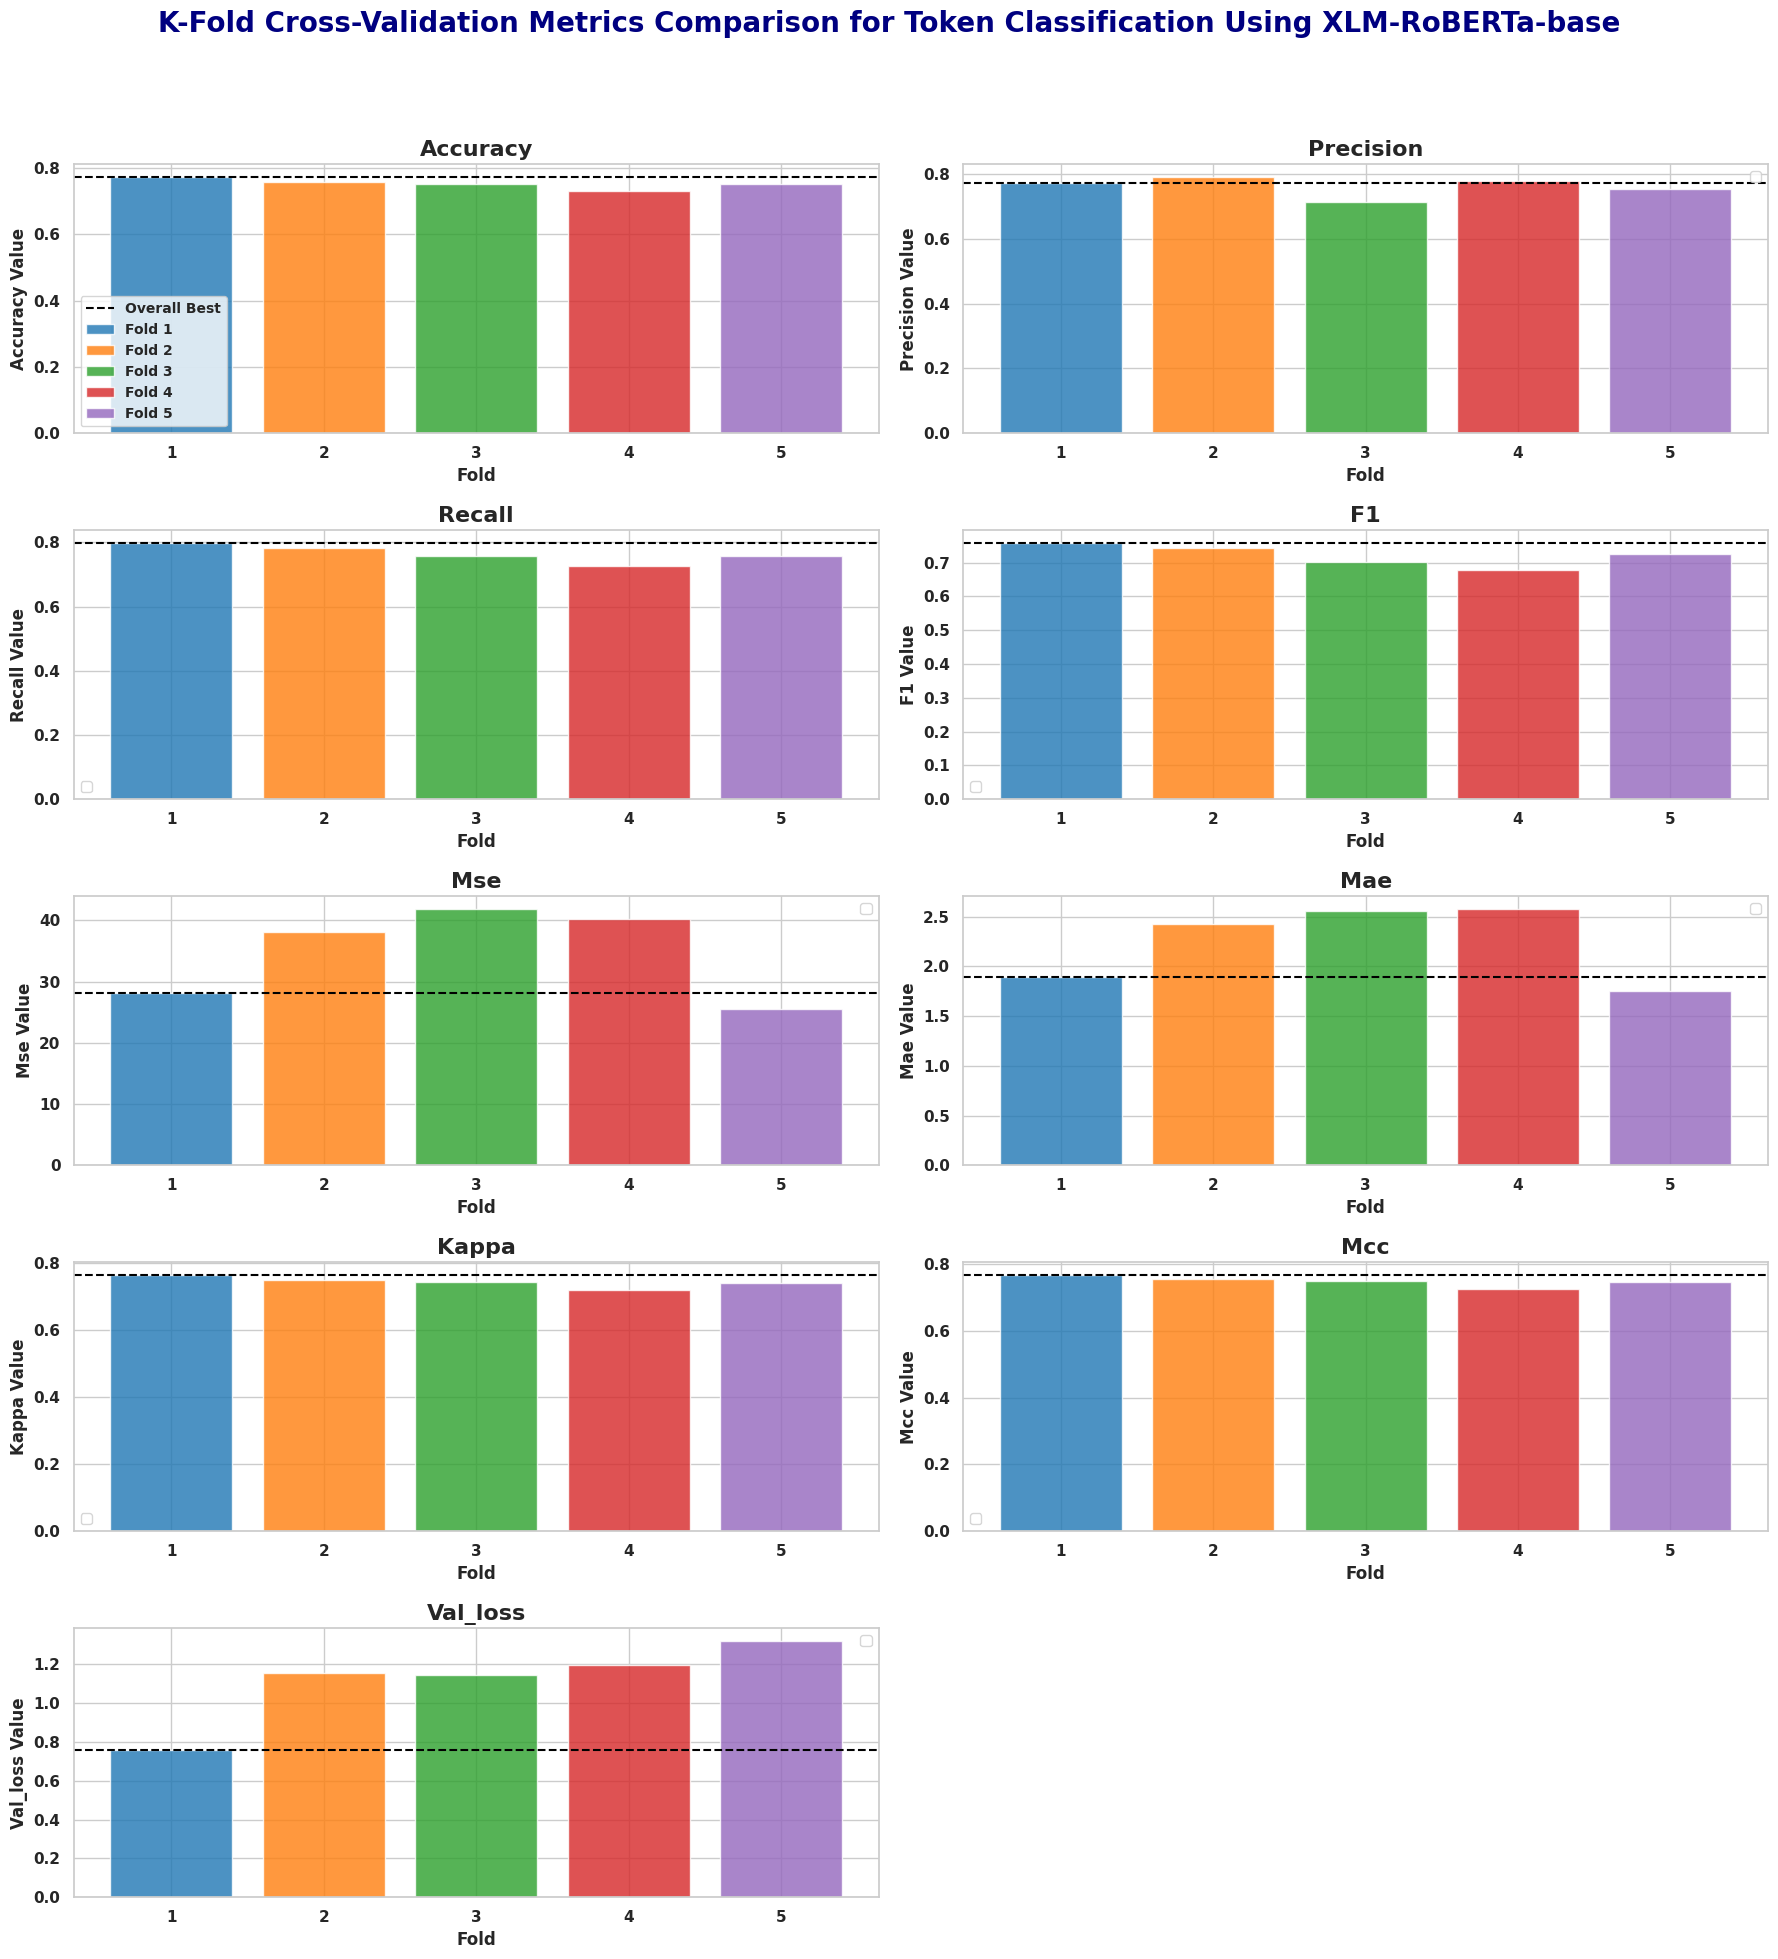

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def training_draw_kfold(fold_scores, overall_best_scores, title, save_path=None):
    # Set overall aesthetics
    sns.set(style="whitegrid")
    font = {'family': 'Courier New', 'weight': 'bold', 'size': 14}
    plt.rc('font', **font)

    # Create figure and axes
    num_folds = len(fold_scores)
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'mse', 'mae', 'kappa', 'mcc', 'val_loss']
    num_metrics = len(metrics)
    rows = (num_metrics + 1) // 2  # Two metrics per row
    f, axes = plt.subplots(rows, 2, figsize=(18, 4 * rows))
    f.subplots_adjust(top=0.93, hspace=0.4, wspace=0.3)
    f.suptitle(title, fontsize=20, weight='bold', color='navy')

    # Flatten axes for easy access
    axes = axes.flatten()

    # Define colors
    colors = sns.color_palette("tab10", num_folds)

    # Plot metrics for each fold
    for i, metric in enumerate(metrics):
        ax = axes[i]
        for fold_idx, fold_score in enumerate(fold_scores):
            ax.bar(
                fold_idx + 1, 
                fold_score[metric], 
                label=f'Fold {fold_idx + 1}' if i == 0 else "", 
                color=colors[fold_idx], 
                alpha=0.8
            )

        # Highlight the overall best score
        ax.axhline(overall_best_scores[metric], color='black', linestyle='--', linewidth=1.5, label='Overall Best' if i == 0 else "")
        ax.set_title(metric.capitalize(), fontsize=16, weight='bold')
        ax.set_xlabel('Fold', fontsize=12, weight='bold')
        ax.set_ylabel(f'{metric.capitalize()} Value', fontsize=12, weight='bold')
        ax.legend(loc="best", fontsize=10)

    # Hide unused subplots
    for j in range(len(metrics), len(axes)):
        axes[j].set_visible(False)

    # Save plot to file if a path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Example usage:
training_draw_kfold(fold_scores, best_scores, 'K-Fold Cross-Validation Metrics Comparison '+title, save_path=title_figure+' kfold_metrics_comparison_plot.png')

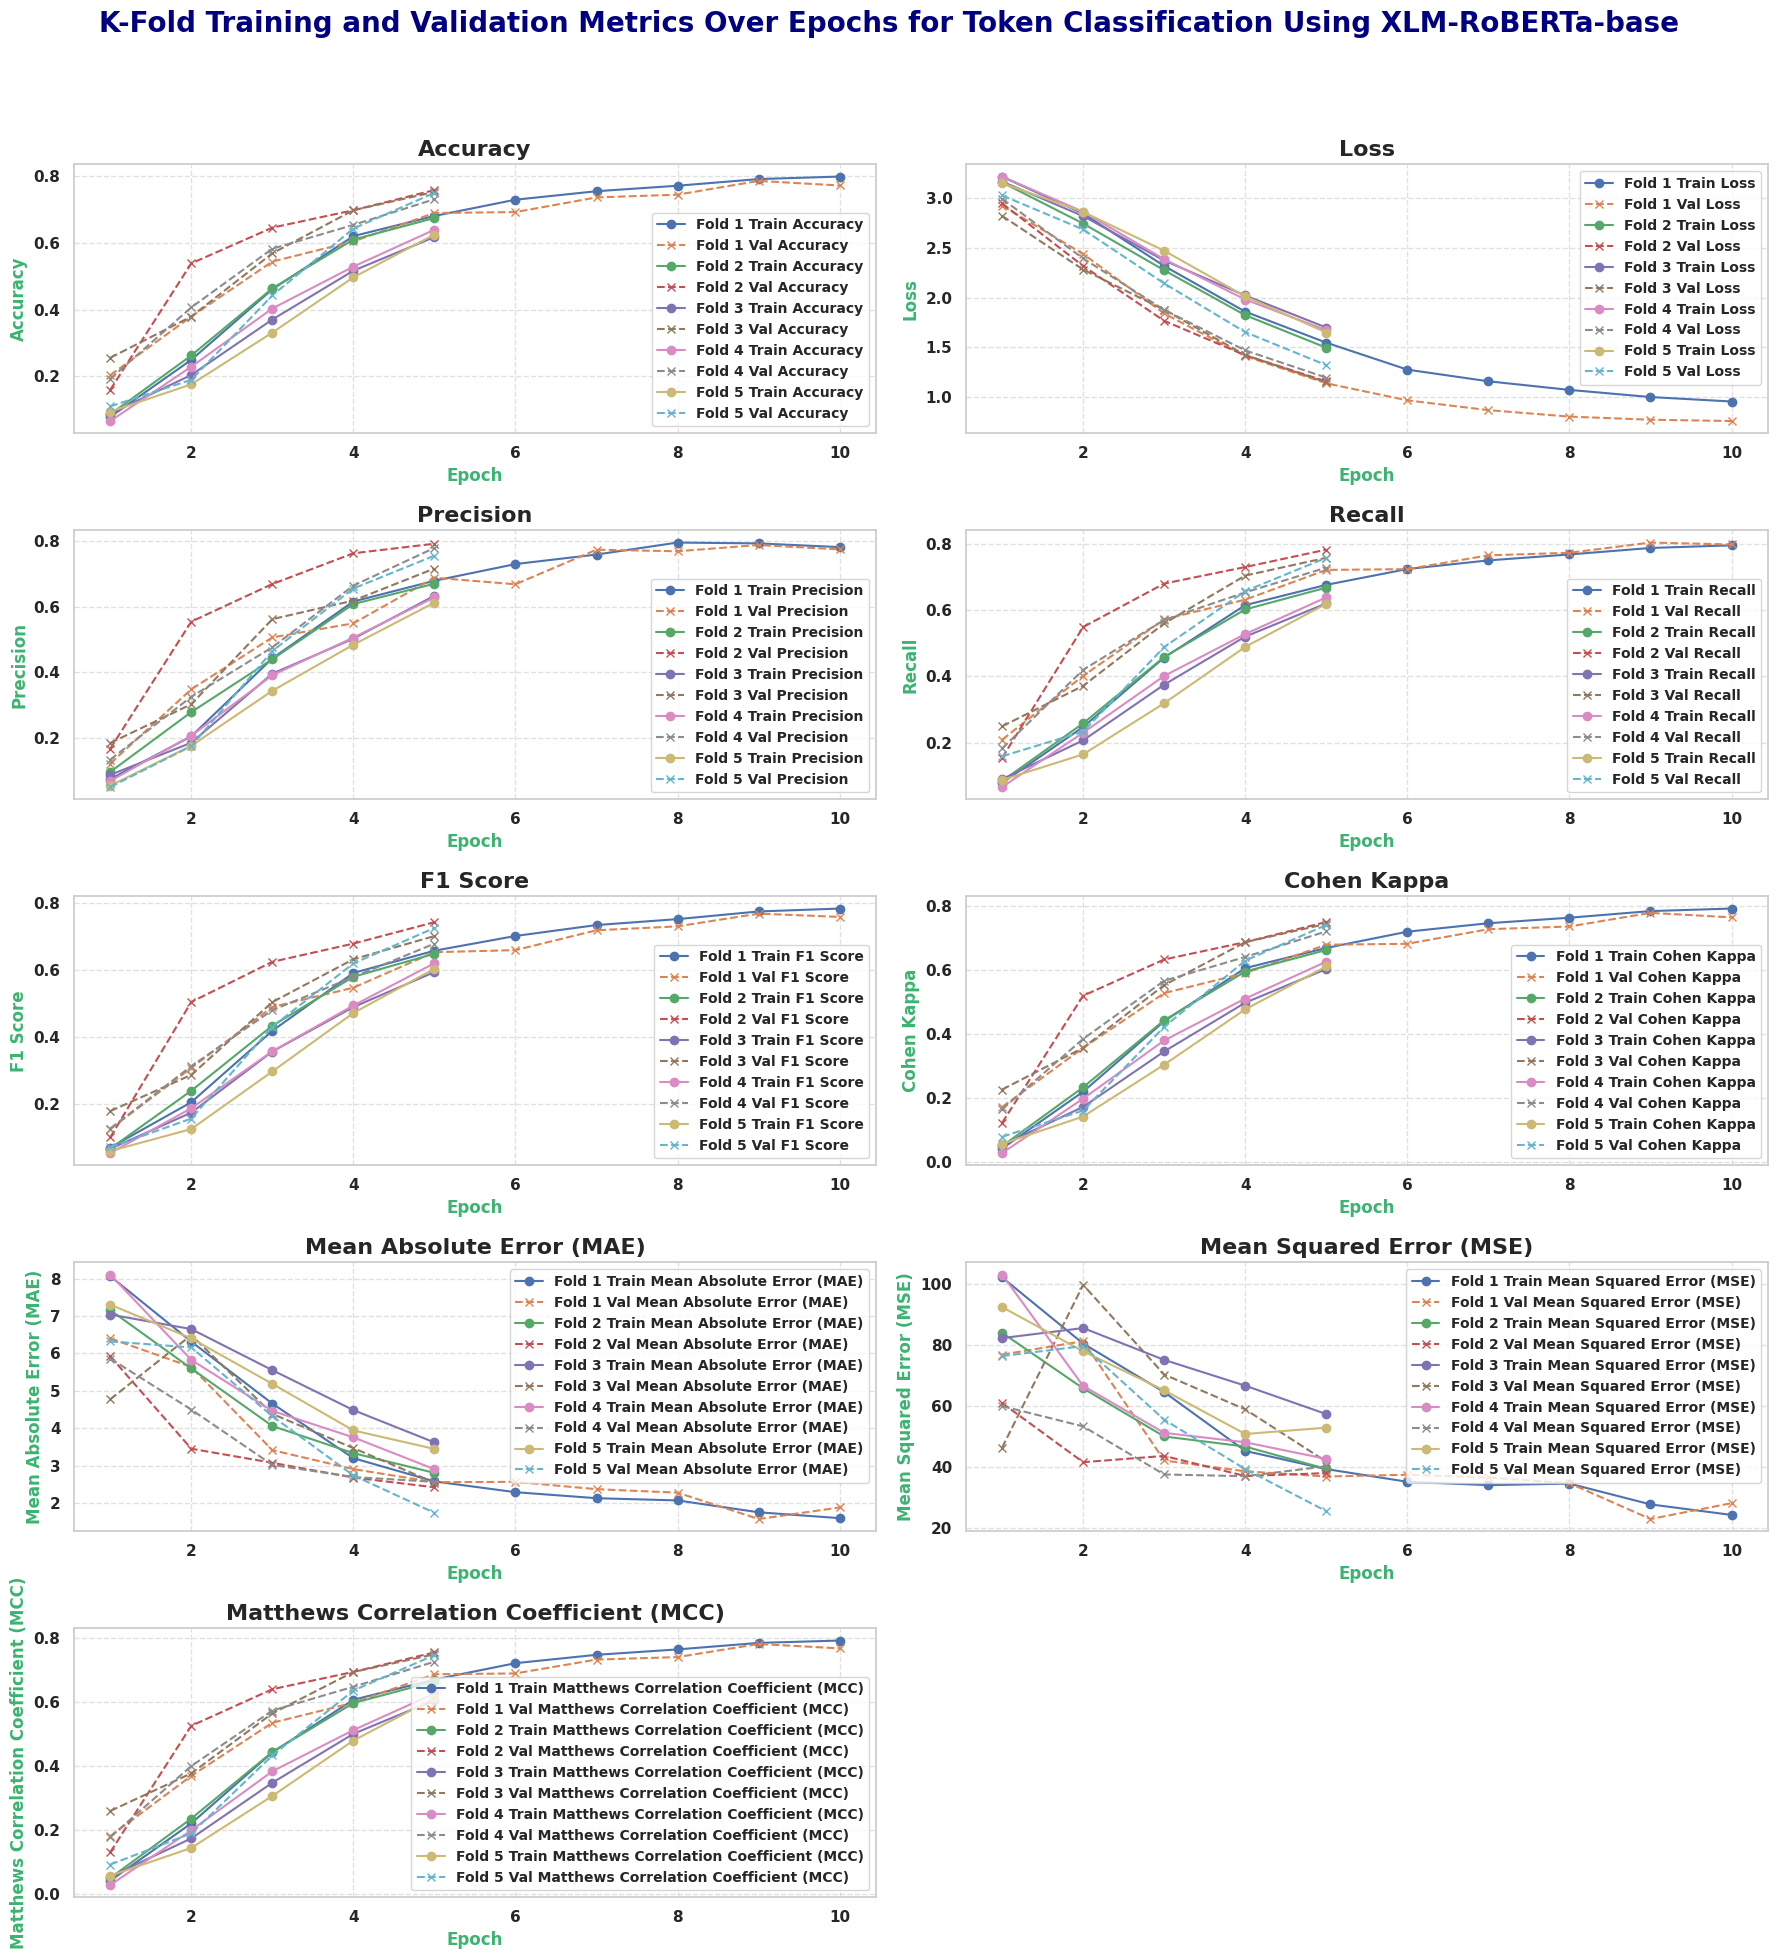

In [42]:
def draw_kfold_training(all_history, title, save_path=None):
    """
    Draw training and validation metrics for all folds in a single image.

    Parameters:
    - all_history: List of histories for each fold, where each history is a dictionary with metrics.
    - title: Title of the overall plot.
    - save_path: Path to save the plot image (optional).
    """
    # Set overall aesthetics
    sns.set(style="whitegrid")
    font = {'family': 'Courier New', 'weight': 'bold', 'size': 14}
    plt.rc('font', **font)

    # Metric names and labels
    metrics = [
        ('accuracy', 'val_accuracy', 'Accuracy'),
        ('loss', 'val_loss', 'Loss'),
        ('precision', 'val_precision', 'Precision'),
        ('recall', 'val_recall', 'Recall'),
        ('f1', 'val_f1', 'F1 Score'),
        ('kappa', 'val_kappa', 'Cohen Kappa'),
        ('mae', 'val_mae', 'Mean Absolute Error (MAE)'),
        ('mse', 'val_mse', 'Mean Squared Error (MSE)'),
        ('mcc', 'val_mcc', 'Matthews Correlation Coefficient (MCC)'),
    ]

    num_metrics = len(metrics)
    rows = (num_metrics + 1) // 2  # Ensure sufficient rows for the metrics
    cols = 2  # Two columns
    
    # Create figure and axes
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
    fig.subplots_adjust(top=0.93, hspace=0.4, wspace=0.4)
    t = fig.suptitle(title, fontsize=20, weight='bold', color='navy')

    # Flatten axes array for easier indexing
    axes = axes.flatten()

    # Define helper function to plot each metric
    def plot_fold_metrics(ax, all_history, train_metric, val_metric, label):
        for fold_idx, history in enumerate(all_history):
            epochs = list(range(1, len(history.get(train_metric, [])) + 1))

            # Train metric
            ax.plot(
                epochs, history.get(train_metric, []),
                label=f'Fold {fold_idx + 1} Train {label}',
                linestyle='-', marker='o', linewidth=1.5
            )

            # Validation metric
            if val_metric in history:
                ax.plot(
                    epochs, history.get(val_metric, []),
                    label=f'Fold {fold_idx + 1} Val {label}',
                    linestyle='--', marker='x', linewidth=1.5
                )

        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_ylabel(label, fontsize=12, color='MediumSeaGreen', weight='bold')
        ax.set_xlabel('Epoch', fontsize=12, color='MediumSeaGreen', weight='bold')
        ax.legend(loc="best", fontsize=10)
        ax.set_title(label, fontsize=16, weight='bold')

    # Iterate through metrics and plot them
    for i, (train_metric, val_metric, label) in enumerate(metrics):
        plot_fold_metrics(axes[i], all_history, train_metric, val_metric, label)

    # Hide unused subplots if any
    for i in range(len(metrics), len(axes)):
        axes[i].axis('off')

    # Final adjustments and save/show the plot
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
draw_kfold_training(all_history, 'K-Fold Training and Validation Metrics Over Epochs '+title, save_path=title_figure+' kfold_training_metrics.png')

In [43]:
from torch.utils.data import DataLoader
test_dataloader = DataLoader(
    tokenized_test_datasets, batch_size=32, collate_fn=data_collator
)

In [44]:
device = config.device

In [45]:
model = ClassifierModel()
model.bert.resize_token_embeddings(len(tokenizer))

Embedding(250002, 768, padding_idx=1)

In [47]:
# Get the fold with the best validation loss (you can change this to another metric if desired)
best_fold_index = np.argmin([score['val_loss'] for score in fold_scores])  # Or use another metric
model_path = f"best_model_fold_{best_fold_index + 1}.pt"  # Assuming model paths are saved as 'best_model_fold_X.pt'
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [48]:
model.to(device)

ClassifierModel(
  (bert): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
       

In [49]:
model.eval()
prediction = []
for batch in test_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(input_ids = batch['input_ids'], attention_mask = batch['attention_mask'])
        logits = outputs
        pred = torch.argmax(logits, dim=-1)
        prediction.extend(pred.cpu().numpy().tolist())

In [50]:
y_true = test_df.LABEL.values
y_pred = prediction

In [51]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    classification_report,
    precision_score,
    recall_score,
    mean_squared_error,
    mean_absolute_error,
    cohen_kappa_score
)
#ypred_cnn_ctw = cnn_ctw_model.predict(x_test_cnn_ctw)

accuray = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

print(model_name)
print("Accuracy:", accuray)
print("precision:", precision)
print("recall:", recall)
print("F1 Score:", f1)
print("MSE:", mse)
print("MAE:", mae)
print("Kappa:", kappa)

XLM-RoBERTa-base
Accuracy: 0.8102564102564103
precision: 0.8145669509680701
recall: 0.8102564102564103
F1 Score: 0.7861275175356314
MSE: 26.1974358974359
MAE: 1.5769230769230769
Kappa: 0.8026666666666666


In [52]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
#labels = ['HAPPY', 'SAD', 'ANGRY', 'FEAR', 'SURPRIZE', 'NEUTRAL']
labels = ['BNG_TEXT', 'ENG_TEXT', 'ORDINAL', 'FLOAT', 'FRACTIONAL', 'DATE',
       'TELEPHONE', 'GAME', 'PERCENTAGE', 'EQUATION', 'HOMO_TEXT', 'RANGE',
       'NON_HOMO_TEXT', 'CARDINAL', 'ROMAN_NUM', 'MONEY', 'ENG_NUM', 'YEAR',
       'TIME', 'ARABIC_TEXT', 'OTHERS_TEXT', 'PUNCTUATION', 'UNKNOWN_TOKEN',
       'SPECIAL SIGN', 'ABBREVIATION', 'EMOZI']
from sklearn import metrics

y_pred_label = [labels[int(x)] for x in y_pred]
y_true_label = [labels[int(x)] for x in y_true]
print(metrics.classification_report(y_true_label, y_pred_label))

               precision    recall  f1-score   support

 ABBREVIATION       0.46      1.00      0.63        30
  ARABIC_TEXT       0.52      0.57      0.54        30
     BNG_TEXT       0.63      0.40      0.49        30
     CARDINAL       0.61      0.83      0.70        30
         DATE       1.00      1.00      1.00        30
        EMOZI       1.00      0.87      0.93        30
      ENG_NUM       0.97      1.00      0.98        30
     ENG_TEXT       0.65      1.00      0.79        30
     EQUATION       1.00      1.00      1.00        30
        FLOAT       1.00      1.00      1.00        30
   FRACTIONAL       1.00      1.00      1.00        30
         GAME       0.88      1.00      0.94        30
    HOMO_TEXT       0.63      0.97      0.76        30
        MONEY       0.93      0.93      0.93        30
NON_HOMO_TEXT       0.89      0.53      0.67        30
      ORDINAL       0.83      0.50      0.62        30
  OTHERS_TEXT       0.00      0.00      0.00        30
   PERCEN

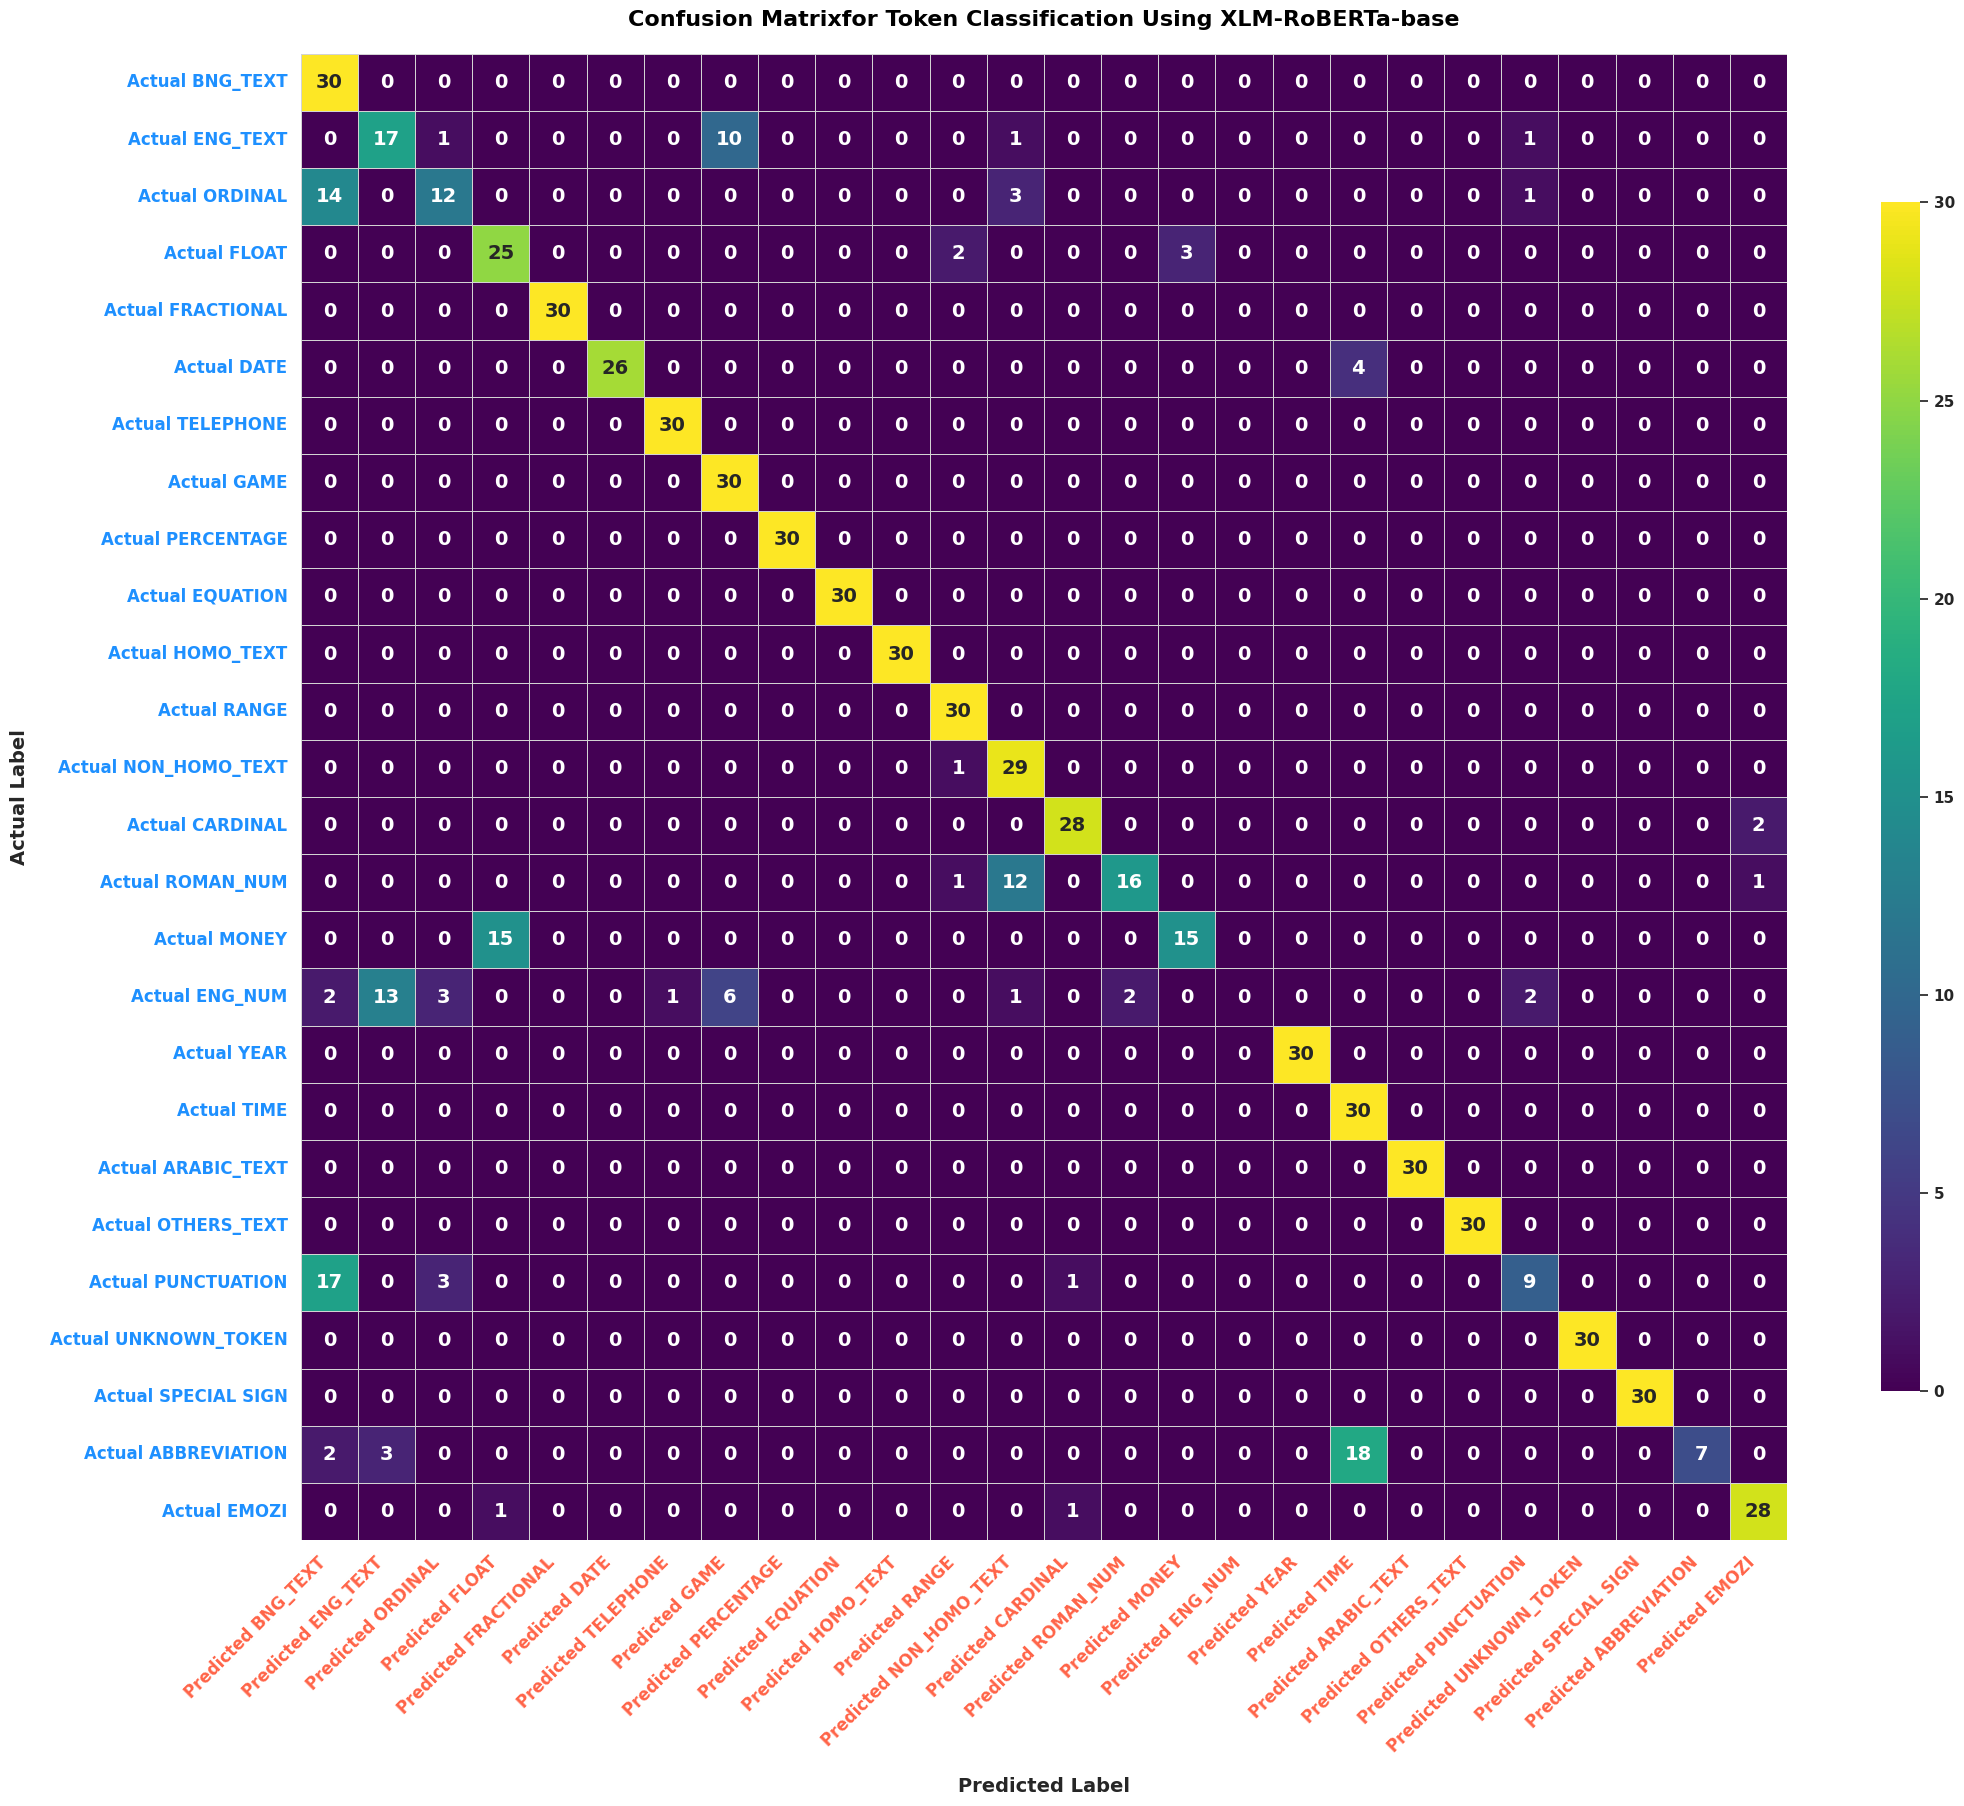

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Set aesthetic parameters for the plot
sns.set(style="white", palette="pastel")  # Lighter and more subtle palette
font = {'family': 'courier new', 'weight': 'bold', 'size': 12}
plt.rc('font', **font)

# Function to plot a light and beautiful confusion matrix
def plot_confusion_matrix(y_true, y_pred, labels, save_path=None):
    columns = [f'Predicted {label}' for label in labels]
    index = [f'Actual {label}' for label in labels]
    
    # Create confusion matrix as a DataFrame
    cm = confusion_matrix(y_true, y_pred)
    table = pd.DataFrame(cm, columns=columns, index=index)
    
    # Set up the figure and axis with lighter, airy sizing
    plt.figure(figsize=(22, 18))
    
    # Create heatmap with a soft, pastel color palette
    sns.heatmap(table, annot=True, fmt='d', cmap='viridis',  # 'Blues' for a soft and clean look
                cbar_kws={'shrink': 0.8, 'aspect': 30},  # Colorbar adjustments
                linewidths=0.5, linecolor='lightgrey',  # Soft gridlines
                annot_kws={"size": 14, "weight": "bold"},  # Softer annotations
                square=True)  # Keep the cells square for balance

    # Add lighter, elegant titles and labels
    plt.title('Confusion Matrix'+title, fontsize=16, weight='bold', pad=20, color='black')
    plt.ylabel('Actual Label', fontsize=14, weight='bold', labelpad=15)
    plt.xlabel('Predicted Label', fontsize=14, weight='bold', labelpad=15)

    # Customizing x and y tick labels for clarity with a soft, clean color
    plt.xticks(rotation=45, ha='right', fontsize=12, weight='bold', color='Tomato')
    plt.yticks(rotation=0, fontsize=12, weight='bold', color='DodgerBlue')
    
    # Tighter layout for a neat appearance
    plt.tight_layout()
        # Save plot to file if a path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')  # Save the plot as a file
    plt.show()


plot_confusion_matrix(y_true_label, y_pred_label, labels, save_path=title_figure+"_confusion_metrics_plot.png")


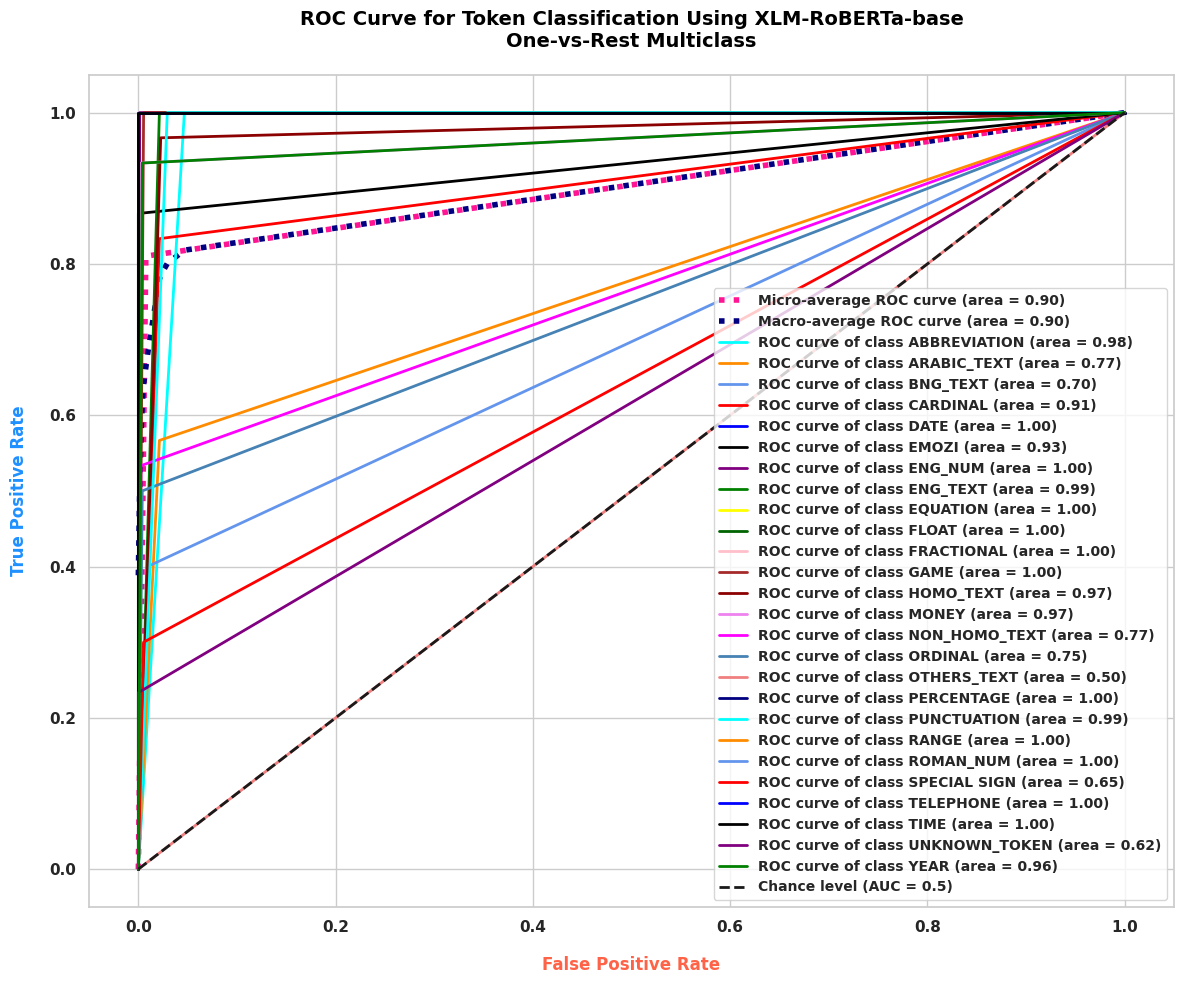

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Set aesthetic parameters for the plot
sns.set(style="whitegrid", palette="pastel")
font = {'family': 'Courier New', 'weight': 'bold', 'size': 12}
plt.rc('font', **font)

# Function to calculate the ROC curve data for multiclass classification
def classification_report_df(y_true, y_pred):
    classes = np.unique(y_true)
    true = label_binarize(y_true, classes=classes)
    pred = label_binarize(y_pred, classes=classes)

    fpr, tpr, roc_auc = {}, {}, {}
    for i, c in enumerate(classes):
        fpr[c], tpr[c], _ = roc_curve(true[:, i], pred[:, i])
        roc_auc[c] = auc(fpr[c], tpr[c])

    # Micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(true.ravel(), pred.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    return fpr, tpr, roc_auc, classes

# Function to plot the ROC curve for multiclass classification
def plot_multiclass_roc(y_true, y_pred, plot_title, save_path=None):
    fpr, tpr, roc_auc, classes = classification_report_df(y_true, y_pred)
    
    # Compute macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[c] for c in classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in classes:
        mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
    mean_tpr /= len(classes)
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Create the plot
    plt.figure(figsize=(12, 10))
    
    # Plot micro-average ROC curve
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average ROC curve (area = {roc_auc["micro"]:0.2f})',
             color='deeppink', linestyle=':', linewidth=4)
    
    # Plot macro-average ROC curve
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Macro-average ROC curve (area = {roc_auc["macro"]:0.2f})',
             color='navy', linestyle=':', linewidth=4)
    
    # Plot ROC curve for each class with different colors
    colors = cycle(["aqua", "darkorange", "cornflowerblue", "red", "blue", "black", "purple", "green", "yellow",
                    "darkgreen", "pink", "brown", "darkred", "violet", "magenta", "steelblue", "lightcoral", "navy"])
    for c, color in zip(classes, colors):
        plt.plot(fpr[c], tpr[c], color=color, lw=2,
                 label=f'ROC curve of class {c} (area = {roc_auc[c]:0.2f})')
    
    # Plot the random guess line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Chance level (AUC = 0.5)")
    
    # Set the plot labels and title
    plt.xlabel("False Positive Rate", fontsize=12, color='Tomato', weight='bold', labelpad=15)
    plt.ylabel("True Positive Rate", fontsize=12, color='DodgerBlue', weight='bold', labelpad=15)
    plt.title(plot_title, fontsize=14, color='black', weight='bold', pad=20)
    
    # Add a legend
    plt.legend(loc="lower right", fontsize=10)
    
    # Adjust layout for better appearance
    plt.tight_layout()
    
    # Save the plot to file if save_path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    # Display the plot
    plt.show()

# Example usage (replace with actual labels and data)
plot_title = "ROC Curve "+title+"\nOne-vs-Rest Multiclass"
plot_multiclass_roc(y_true_label, y_pred_label, plot_title, save_path=title_figure+"_roc_plot.png")